# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

**Architecture**
- 3 QConv2D layers with QBatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: QDense(NUM_CLASSES) (logits output, no softmax)

**Quantization Strategy (HGQ2)**
- Fixed 8-bit quantization (`k0=0`) for both weights and activations
- `kbi` quantizer for weights (SAT_SYM overflow)
- `kif` quantizer for activations (WRAP overflow)
- Effective Bit-Operations (EBOPs) tracking for resource estimation

This notebook follows the HGQ2 best-practice patterns demonstrated in:
- [1] `small_jet_tagger.ipynb`
- [2] `larger_jet_tagger.ipynb`

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 15
- Max epochs: 50

## Imports

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset, preprocess_data
from bedposip.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
    inspect_quantization_bits, 
    plot_quantization_bits
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope, LayerConfigScope
from hgq.utils import trace_minmax
from hgq.regularizers import MonoL1

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

In [24]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Constant for training quantizers bit-width optimizations
REGULARIZER = 1e-5

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [25]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [26]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [27]:
# Define callbacks using package function
# BetaPID dynamically adjusts beta to steer the model toward a target EBOPs budget.
callbacks = get_callbacks(
    model_name='qat',
    patience=30,
    track_ebops=True,
    target_ebops=800_000,
    init_beta=1e-7,
)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - FreeEBOPs
  - BetaPID


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: Fixed 8-bit (4 integer + 4 fractional) with symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): Fixed 8-bit (4 integer + 4 fractional) with wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [28]:
from hgq.constraints import MinMax, Max
from hgq.regularizers import MonoL1

with (
    QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
    QuantizerConfigScope(
        place='weight',
        bc=Max(6),
        ic=Max(4),
        i0=2, b0=6,
        br=MonoL1(REGULARIZER),
        ir=MonoL1(REGULARIZER),
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='bias',
        bc=Max(3),
        ic=Max(3),
        i0=2, b0=4,
        br=MonoL1(REGULARIZER),
        ir=MonoL1(REGULARIZER),
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='datalane',
        fc=Max(3),
        ic=Max(6),
        i0=3, f0=3,
        ir=MonoL1(REGULARIZER),
        fr=MonoL1(REGULARIZER),
        default_q_type='kif', overflow_mode='WRAP'
    ),
    LayerConfigScope(enable_ebops=True),  # beta managed by BetaPID callback
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()

Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 8, 8, 16)       │           771 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (QBatchNormalization) │ (None, 4, 4, 16)       │           931 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 16)       │         9,987 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (QBatchNormalization) │ (None, 2, 2, 16)       │           355 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 24)       │        14,019 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (QBatchNormalization) │ (None, 2, 2, 24)       │           531 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 42)             │        16,587 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1                      │ (None, 42)             │           549 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 64)             │        11,137 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2                      │ (None, 64)             │           835 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,677 (179.33 KB)

 Trainable params: 40,855 (159.59 KB)

 Non-trainable params: 15,822 (19.74 KB)

In [29]:
check_layer_trainable_params(model_qat)

qconv_1: 144
bn_conv_1: 16
qconv_2: 2304
bn_conv_2: 16
qconv_3: 3456
bn_conv_3: 24
qdense_1: 4032
bn_dense_1: 42
qdense_2: 2688
bn_dense_2: 64
output: 192


### Training

Epoch 1/300


I0000 00:00:1780628613.895619  149139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_549198__.145


51/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4889 - loss: 2.3345

I0000 00:00:1780628623.980642  149141 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_549198__.145


59/59 ━━━━━━━━━━━━━━━━━━━━ 35s 301ms/step - accuracy: 0.5888 - loss: 2.1702 - val_accuracy: 0.3334 - val_loss: 3.3770 - learning_rate: 0.0010 - ebops: 2005401.0000 - beta: 1.0000e-07
Epoch 2/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7643 - loss: 1.8444 - val_accuracy: 0.4837 - val_loss: 2.6846 - learning_rate: 0.0010 - ebops: 1952577.0000 - beta: 1.0000e-07
Epoch 3/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8042 - loss: 1.7477 - val_accuracy: 0.5724 - val_loss: 2.0589 - learning_rate: 0.0010 - ebops: 1938783.0000 - beta: 1.0000e-07
Epoch 4/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8210 - loss: 1.7035 - val_accuracy: 0.6138 - val_loss: 2.1014 - learning_rate: 0.0010 - ebops: 1940535.0000 - beta: 1.0000e-07
Epoch 5/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8338 - loss: 1.6688 - val_accuracy: 0.6908 - val_loss: 1.8410 - learning_rate: 0.0010 - ebops: 1937733.0000 - beta: 1.0000e-07
Epoch 6/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

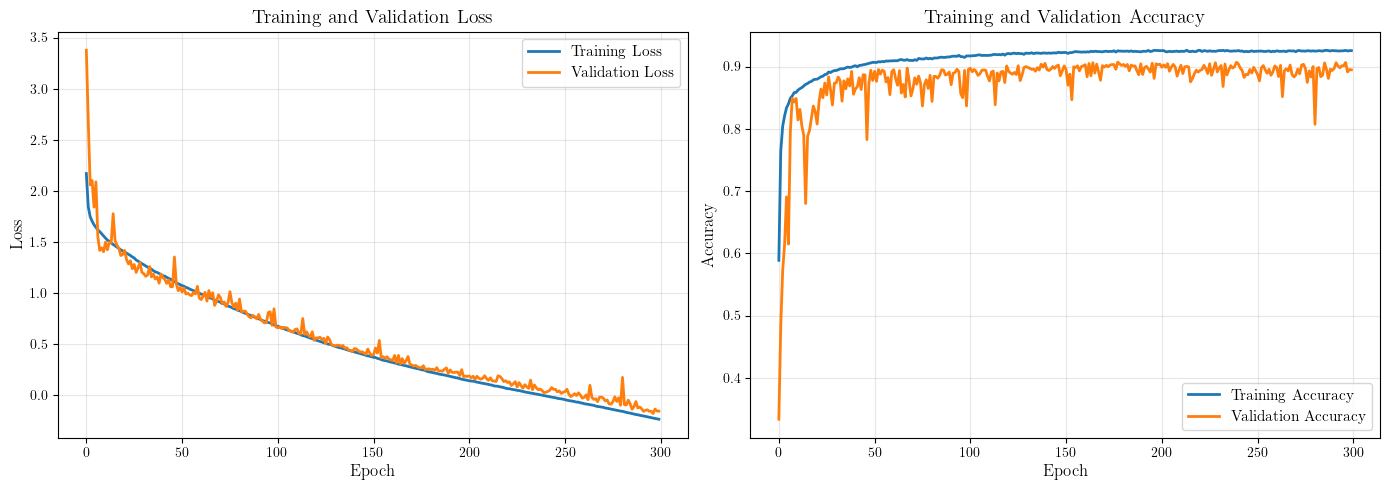

In [30]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2048, epochs=300) # Batch according to HGQ article
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

## Model Evaluation

In [31]:
class_report_metric(model_qat, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_qat`:
  Loss: -0.1746
  Accuracy: 90.41%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.9077    0.9030    0.9053     40000
   lateral_R     0.8919    0.9194    0.9054     40000
      supine     0.9134    0.8899    0.9015     40001

    accuracy                         0.9041    120001
   macro avg     0.9043    0.9041    0.9041    120001
weighted avg     0.9043    0.9041    0.9041    120001



In [32]:
# Inspect learned quantization bit-widths
# bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


In [33]:
# From larger_jet_tagger

# When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. 
trace_minmax(model_qat, X_train, batch_size=2048, reset=True)
ebops = trace_minmax(model_qat, X_val, batch_size=2048, reset=False)

lut_pred = np.exp(0.985 * np.log(ebops))
dsp_pred = (ebops - lut_pred) / 55

print("Resource Estimation Report")
print("="*40)
print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

Resource Estimation Report

EBOPs: 426856 
LUTs: 351421 
DSPs: 1372


In [34]:
## Determine accuracy of Keras model, for comparison
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)

print("="*80)    
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("="*80)

Keras  model evaluation 	 Loss: 0.76 	 Accuracy: 67.64%


In [35]:
# Inspect learned quantization bit-widths
bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


Quantization Bit-width Report:
pressure_map: InputLayer (no quantizers)

qconv_1 (QConv2D):
  iq: bits=5.02, fbits=5.02, type=kif
  kq: bits=3.26, fbits=4.26, type=kbi
pool_1: MaxPooling2D (no quantizers)

bn_conv_1 (QBatchNormalization):
  iq: bits=4.62, fbits=5.42, type=kif
  kq: bits=5.56, fbits=6.56, type=kbi
  bq: bits=2.81, fbits=3.81, type=kbi
conv_act_1: Activation (no quantizers)

qconv_2 (QConv2D):
  iq: bits=5.06, fbits=5.06, type=kif
  kq: bits=1.66, fbits=2.66, type=kbi
pool_2: MaxPooling2D (no quantizers)

bn_conv_2 (QBatchNormalization):
  iq: bits=6.98, fbits=7.92, type=kif
  kq: bits=5.25, fbits=6.25, type=kbi
  bq: bits=2.88, fbits=3.88, type=kbi
conv_act_2: Activation (no quantizers)

qconv_3 (QConv2D):
  iq: bits=6.47, fbits=6.47, type=kif
  kq: bits=0.96, fbits=1.96, type=kbi

bn_conv_3 (QBatchNormalization):
  iq: bits=6.17, fbits=7.17, type=kif
  kq: bits=4.21, fbits=5.21, type=kbi
  bq: bits=2.67, fbits=3.67, type=kbi
conv_act_3: Activation (no quantizers)
flat

## Model Saving

In [36]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 56,677
